# Healthcare Claims Analytics Dashboard
### Python Analysis Notebook

This notebook covers the full analytics workflow used to power the Power BI dashboard:

1. Data Loading & Inspection
2. Data Cleaning & Missing Value Handling
3. KPI Calculations
4. Trend Analysis (monthly, payer, provider)
5. Visualizations (denials, AR aging, collections)

**Dataset:** `data/claims_data.csv` (synthetic healthcare claims data)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv("../data/claims_data.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (5015, 17)


,Claim_ID,Patient_ID,Provider,Insurance_Payer,CPT_Code,ICD10_Code,Date_of_Service,Billed_Amount,Allowed_Amount,Paid_Amount,Adjustment_Amount,Denial_Code,Denial_Reason,Claim_Status,Days_in_AR,Place_of_Service,State
0,CLM100001,PAT17270,Dr. Robert Kim,Molina Healthcare,97110,N39.0,2024-07-07,4027.93,3664.82,3518.64,363.11,NaN,NaN,Paid,28.0,Inpatient Hospital,MI
1,CLM100002,PAT18322,Dr. Michael Brown,Medicare,71046,M25.561,2024-10-20,246.72,160.89,145.17,85.83,NaN,NaN,Paid,31.0,Office,IL
2,CLM100003,PAT19274,Dr. Kevin Patel,Medicare,90834,I25.10,2024-07-08,183.26,0.00,0.00,0.00,NaN,NaN,In Review,17.0,Office,NY
3,CLM100004,PAT13556,Dr. Priya Nair,Aetna,29881,F41.9,2024-09-30,2804.17,2016.95,1863.87,787.22,NaN,NaN,Paid,11.0,Ambulatory Surgical Center,CA
4,CLM100005,PAT10775,Dr. Priya Nair,Kaiser Permanente,99283,I10,2024-12-25,965.41,636.59,626.55,328.82,NaN,NaN,Paid,38.0,Emergency Room,OH


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Claim_ID           5015 non-null   str    
 1   Patient_ID         5015 non-null   str    
 2   Provider           5015 non-null   str    
 3   Insurance_Payer    5015 non-null   str    
 4   CPT_Code           5015 non-null   int64  
 5   ICD10_Code         5015 non-null   str    
 6   Date_of_Service    5015 non-null   str    
 7   Billed_Amount      5015 non-null   float64
 8   Allowed_Amount     5015 non-null   float64
 9   Paid_Amount        5015 non-null   float64
 10  Adjustment_Amount  5015 non-null   float64
 11  Denial_Code        1422 non-null   str    
 12  Denial_Reason      1422 non-null   str    
 13  Claim_Status       5015 non-null   str    
 14  Days_in_AR         4955 non-null   float64
 15  Place_of_Service   5015 non-null   str    
 16  State              5015 non-null   

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Claim_ID,5015,5000,CLM100793,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Patient_ID,5015,3930,PAT14823,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Provider,5015,10,Dr. Kevin Patel,544,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insurance_Payer,5015,9,Medicare,995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPT_Code,5015.0,NaN,NaN,NaN,75020.49332,28835.815974,12001.0,45378.0,90834.0,99213.0,99283.0
ICD10_Code,5015,15,F41.9,378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_of_Service,5015,365,2024-09-02,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billed_Amount,5015.0,NaN,NaN,NaN,1540.100718,2824.799605,60.6,180.52,313.94,1277.73,14987.12
Allowed_Amount,5015.0,NaN,NaN,NaN,886.91069,1947.820579,0.0,43.925,165.94,538.175,13650.21
Paid_Amount,5015.0,NaN,NaN,NaN,812.163384,1812.135492,0.0,29.6,150.89,499.86,12940.72


## 2. Data Cleaning & Missing Value Handling

Steps performed:
- Remove exact duplicate claim rows
- Convert `Date_of_Service` to datetime
- Handle missing values in `Days_in_AR`
- Standardize text fields (denial reason, payer, provider)
- Add derived columns (Claim_Month, AR_Bucket)


In [5]:
# --- Check for duplicates ---
dupe_count = df.duplicated(subset=["Claim_ID"]).sum()
print(f"Duplicate Claim_IDs found: {dupe_count}")

df = df.drop_duplicates(subset=["Claim_ID"], keep="first").reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")


Duplicate Claim_IDs found: 15
Shape after removing duplicates: (5000, 17)


In [6]:
# --- Check missing values ---
df.isnull().sum()


Claim_ID                0
Patient_ID              0
Provider                0
Insurance_Payer         0
CPT_Code                0
ICD10_Code              0
Date_of_Service         0
Billed_Amount           0
Allowed_Amount          0
Paid_Amount             0
Adjustment_Amount       0
Denial_Code          3580
Denial_Reason        3580
Claim_Status            0
Days_in_AR             60
Place_of_Service        0
State                   0
dtype: int64

In [7]:
# --- Convert date column ---
df["Date_of_Service"] = pd.to_datetime(df["Date_of_Service"])

# --- Handle missing Days_in_AR: impute using payer-level median ---
df["Days_in_AR"] = df.groupby("Insurance_Payer")["Days_in_AR"].transform(
    lambda x: x.fillna(x.median())
)
df["Days_in_AR"] = df["Days_in_AR"].round(0).astype(int)

# --- Standardize text fields ---
text_cols = ["Provider", "Insurance_Payer", "Claim_Status", "Denial_Reason", "Place_of_Service", "State"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df.replace({"Denial_Reason": {"nan": ""}, "Denial_Code": {"nan": ""}}, inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())


Missing values after cleaning:
7160


In [8]:
# --- Derived columns ---
df["Claim_Month"] = df["Date_of_Service"].dt.to_period("M").astype(str)

def ar_bucket(days):
    if days <= 30:
        return "0-30 Days"
    elif days <= 60:
        return "31-60 Days"
    elif days <= 90:
        return "61-90 Days"
    else:
        return "90+ Days"

df["AR_Bucket"] = df["Days_in_AR"].apply(ar_bucket)

# Save cleaned dataset for use in Power BI / further analysis
df.to_csv("../data/claims_data_cleaned.csv", index=False)
df.head()


,Claim_ID,Patient_ID,Provider,Insurance_Payer,CPT_Code,ICD10_Code,Date_of_Service,Billed_Amount,Allowed_Amount,Paid_Amount,Adjustment_Amount,Denial_Code,Denial_Reason,Claim_Status,Days_in_AR,Place_of_Service,State,Claim_Month,AR_Bucket
0,CLM100001,PAT17270,Dr. Robert Kim,Molina Healthcare,97110,N39.0,2024-07-07,4027.93,3664.82,3518.64,363.11,NaN,NaN,Paid,28,Inpatient Hospital,MI,2024-07,0-30 Days
1,CLM100002,PAT18322,Dr. Michael Brown,Medicare,71046,M25.561,2024-10-20,246.72,160.89,145.17,85.83,NaN,NaN,Paid,31,Office,IL,2024-10,31-60 Days
2,CLM100003,PAT19274,Dr. Kevin Patel,Medicare,90834,I25.10,2024-07-08,183.26,0.00,0.00,0.00,NaN,NaN,In Review,17,Office,NY,2024-07,0-30 Days
3,CLM100004,PAT13556,Dr. Priya Nair,Aetna,29881,F41.9,2024-09-30,2804.17,2016.95,1863.87,787.22,NaN,NaN,Paid,11,Ambulatory Surgical Center,CA,2024-09,0-30 Days
4,CLM100005,PAT10775,Dr. Priya Nair,Kaiser Permanente,99283,I10,2024-12-25,965.41,636.59,626.55,328.82,NaN,NaN,Paid,38,Emergency Room,OH,2024-12,31-60 Days


## 3. KPI Calculations

In [9]:
total_claims = len(df)
total_billed = df["Billed_Amount"].sum()
total_paid = df["Paid_Amount"].sum()
collection_rate = round(total_paid / total_billed * 100, 2)

denied_claims = (df["Claim_Status"] == "Denied").sum()
denial_rate = round(denied_claims / total_claims * 100, 2)

# First-Pass Resolution Rate: claims paid in full with no denial/partial-pay cycle
first_pass_resolved = (df["Claim_Status"] == "Paid").sum()
first_pass_rate = round(first_pass_resolved / total_claims * 100, 2)

avg_days_in_ar = round(df["Days_in_AR"].mean(), 1)

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Claims", "Total Billed Amount", "Total Paid Amount",
        "Collection Rate (%)", "Denial Rate (%)",
        "First-Pass Resolution Rate (%)", "Average Days in AR"
    ],
    "Value": [
        total_claims, f"${total_billed:,.2f}", f"${total_paid:,.2f}",
        collection_rate, denial_rate, first_pass_rate, avg_days_in_ar
    ]
})
kpi_summary


,KPI,Value
0,Total Claims,5000
1,Total Billed Amount,"$7,696,184.99"
2,Total Paid Amount,"$4,054,246.52"
3,Collection Rate (%),52.68
4,Denial Rate (%),14.92
5,First-Pass Resolution Rate (%),61.78
6,Average Days in AR,34.9


In [10]:
# --- Top Denial Reasons ---
top_denials = (
    df[df["Denial_Reason"] != ""]
    .groupby("Denial_Reason")
    .agg(Denial_Count=("Claim_ID", "count"), Lost_Revenue=("Billed_Amount", "sum"))
    .sort_values("Denial_Count", ascending=False)
    .reset_index()
)
top_denials


,Denial_Reason,Denial_Count,Lost_Revenue
0,Benefit included in another service already paid,160,272754.57
1,Coordination of benefits issue,154,216847.36
2,Coinsurance amount owed by patient,150,199810.67
3,Claim/service lacks information needed for adj...,149,194136.59
4,Charge exceeds fee schedule/maximum allowable,142,165169.13
5,Deductible amount not met,141,319987.32
6,Timely filing limit expired,135,210458.00
7,Diagnosis code inconsistent with procedure,133,169472.98
8,Duplicate claim/service,129,183336.63
9,Non-covered service - not medically necessary,127,235610.24


In [11]:
# --- Claims by Payer ---
claims_by_payer = (
    df.groupby("Insurance_Payer")
    .agg(
        Total_Claims=("Claim_ID", "count"),
        Total_Billed=("Billed_Amount", "sum"),
        Total_Paid=("Paid_Amount", "sum"),
    )
    .assign(Collection_Rate_Pct=lambda x: round(x["Total_Paid"] / x["Total_Billed"] * 100, 2))
    .sort_values("Total_Billed", ascending=False)
    .reset_index()
)
claims_by_payer


,Insurance_Payer,Total_Claims,Total_Billed,Total_Paid,Collection_Rate_Pct
0,Medicare,993,1541240.58,894296.97,58.02
1,UnitedHealthcare,773,1269545.17,653180.71,51.45
2,Anthem BCBS,667,984835.10,511351.31,51.92
3,Medicaid,565,899521.40,431929.00,48.02
4,Aetna,494,752797.85,446557.11,59.32
5,Cigna,501,697932.19,332634.55,47.66
6,Kaiser Permanente,342,584829.92,310189.68,53.04
7,Humana,420,565515.73,267273.94,47.26
8,Molina Healthcare,245,399967.05,206833.25,51.71


In [12]:
# --- Claims by Provider ---
claims_by_provider = (
    df.groupby("Provider")
    .agg(
        Total_Claims=("Claim_ID", "count"),
        Total_Billed=("Billed_Amount", "sum"),
        Total_Paid=("Paid_Amount", "sum"),
        Avg_Days_in_AR=("Days_in_AR", "mean"),
    )
    .assign(Collection_Rate_Pct=lambda x: round(x["Total_Paid"] / x["Total_Billed"] * 100, 2))
    .sort_values("Total_Paid", ascending=False)
    .reset_index()
)
claims_by_provider


,Provider,Total_Claims,Total_Billed,Total_Paid,Avg_Days_in_AR,Collection_Rate_Pct
0,Dr. James Carter,514,894853.31,467242.17,33.961089,52.21
1,Dr. Priya Nair,499,882066.65,458435.65,34.949900,51.97
2,Dr. Michael Brown,469,807673.13,422560.06,35.466951,52.32
3,Dr. Kevin Patel,544,794986.17,416096.60,35.788603,52.34
4,Dr. Robert Kim,488,746050.34,408770.55,35.979508,54.79
5,Dr. Ana Rodriguez,509,759455.11,393036.89,35.528487,51.75
6,Dr. Sarah Mitchell,496,713133.36,386101.83,33.635081,54.14
7,Dr. Emily Chen,494,743375.14,382573.94,35.172065,51.46
8,Dr. Laura Thompson,512,660285.31,361494.86,34.593750,54.75
9,Dr. David Wilson,475,694306.47,357933.97,33.637895,51.55


## 4. Trend Analysis

In [13]:
monthly_trend = (
    df.groupby("Claim_Month")
    .agg(
        Total_Claims=("Claim_ID", "count"),
        Total_Billed=("Billed_Amount", "sum"),
        Total_Paid=("Paid_Amount", "sum"),
    )
    .assign(Collection_Rate_Pct=lambda x: round(x["Total_Paid"] / x["Total_Billed"] * 100, 2))
    .reset_index()
    .sort_values("Claim_Month")
)
monthly_trend


,Claim_Month,Total_Claims,Total_Billed,Total_Paid,Collection_Rate_Pct
0,2024-01,448,588694.06,317008.64,53.85
1,2024-02,376,585026.06,331129.19,56.60
2,2024-03,368,534851.38,311757.20,58.29
3,2024-04,440,751703.81,372897.97,49.61
4,2024-05,434,670281.40,332634.42,49.63
5,2024-06,408,558875.33,293815.92,52.57
6,2024-07,444,642393.07,312945.76,48.72
7,2024-08,449,696648.26,378427.30,54.32
8,2024-09,422,648207.90,312475.32,48.21
9,2024-10,392,704381.83,356491.93,50.61


In [14]:
ar_aging = (
    df.groupby("AR_Bucket")
    .agg(Claim_Count=("Claim_ID", "count"), Billed_Amount=("Billed_Amount", "sum"))
    .reindex(["0-30 Days", "31-60 Days", "61-90 Days", "90+ Days"])
    .reset_index()
)
ar_aging


,AR_Bucket,Claim_Count,Billed_Amount
0,0-30 Days,2482,3691073.09
1,31-60 Days,1870,3038155.84
2,61-90 Days,428,657927.41
3,90+ Days,220,309028.65


## 5. Visualizations

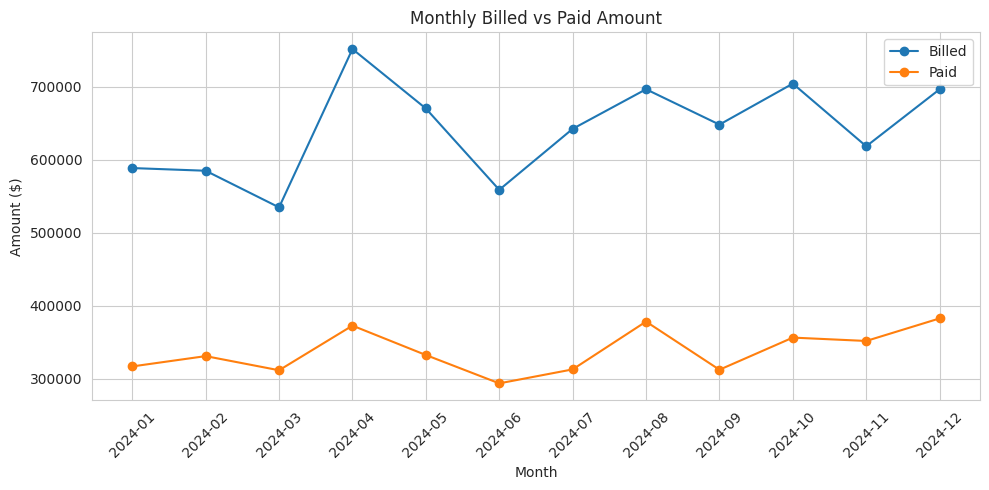

In [15]:
# Monthly billed vs paid trend
fig, ax = plt.subplots()
ax.plot(monthly_trend["Claim_Month"], monthly_trend["Total_Billed"], marker="o", label="Billed")
ax.plot(monthly_trend["Claim_Month"], monthly_trend["Total_Paid"], marker="o", label="Paid")
ax.set_title("Monthly Billed vs Paid Amount")
ax.set_xlabel("Month")
ax.set_ylabel("Amount ($)")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig("../images/monthly_trend.png", dpi=150)
plt.show()


/tmp/ipykernel_873/2585605761.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_denials, x="Denial_Count", y="Denial_Reason", palette="Reds_r", ax=ax)


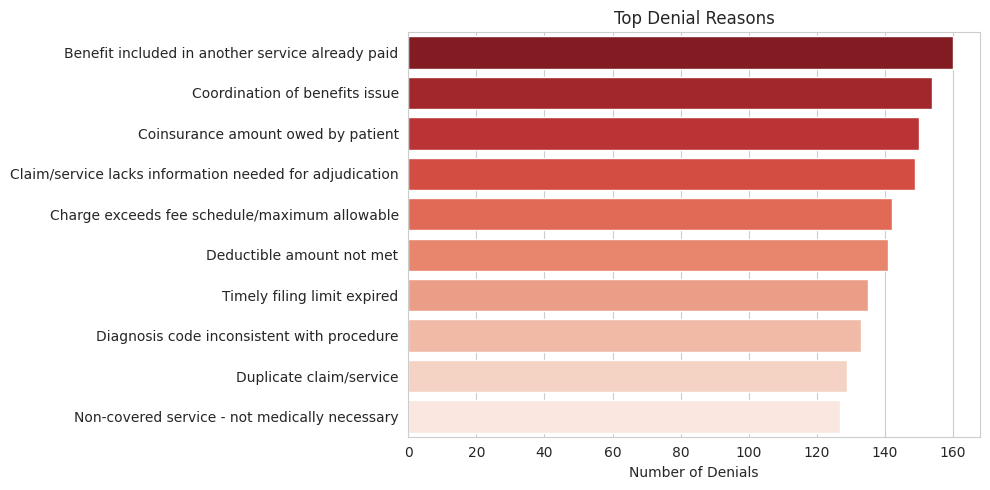

In [16]:
# Top denial reasons
fig, ax = plt.subplots()
sns.barplot(data=top_denials, x="Denial_Count", y="Denial_Reason", palette="Reds_r", ax=ax)
ax.set_title("Top Denial Reasons")
ax.set_xlabel("Number of Denials")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../images/top_denial_reasons.png", dpi=150)
plt.show()


/tmp/ipykernel_873/3501288681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=claims_by_payer, x="Collection_Rate_Pct", y="Insurance_Payer", palette="Blues_r", ax=ax)


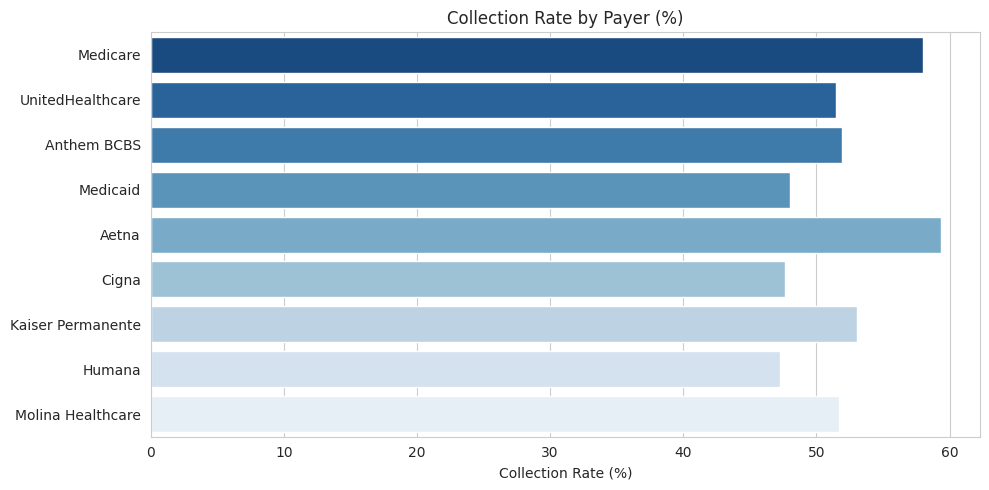

In [17]:
# Claims by payer - collection rate
fig, ax = plt.subplots()
sns.barplot(data=claims_by_payer, x="Collection_Rate_Pct", y="Insurance_Payer", palette="Blues_r", ax=ax)
ax.set_title("Collection Rate by Payer (%)")
ax.set_xlabel("Collection Rate (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../images/collection_rate_by_payer.png", dpi=150)
plt.show()


/tmp/ipykernel_873/2413621384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ar_aging, x="AR_Bucket", y="Claim_Count", palette="Oranges", ax=ax)


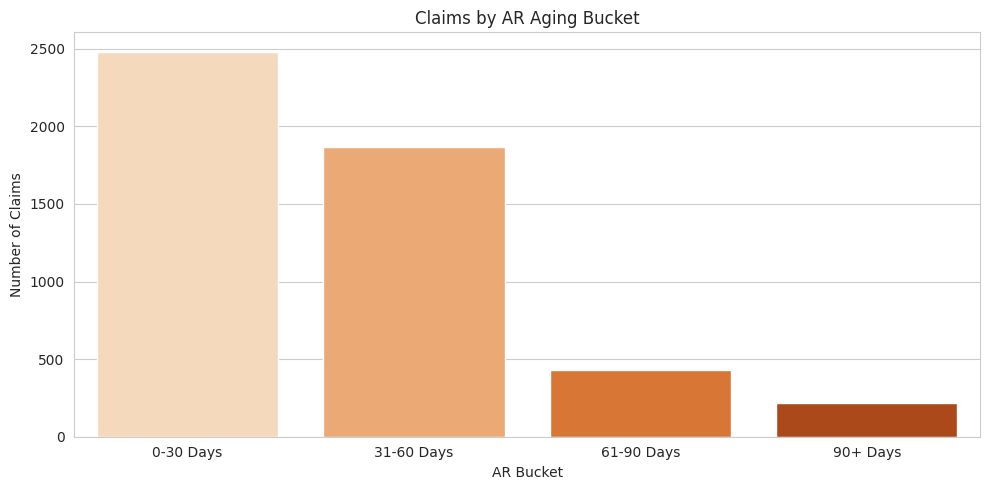

In [18]:
# AR Aging distribution
fig, ax = plt.subplots()
sns.barplot(data=ar_aging, x="AR_Bucket", y="Claim_Count", palette="Oranges", ax=ax)
ax.set_title("Claims by AR Aging Bucket")
ax.set_xlabel("AR Bucket")
ax.set_ylabel("Number of Claims")
plt.tight_layout()
plt.savefig("../images/ar_aging.png", dpi=150)
plt.show()


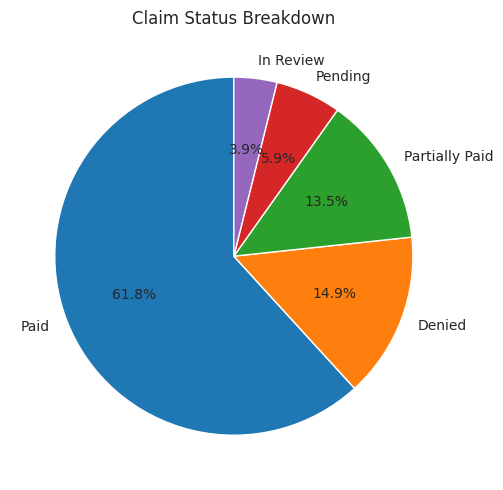

In [19]:
# Claim status breakdown (pie chart)
status_counts = df["Claim_Status"].value_counts()
fig, ax = plt.subplots()
ax.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Claim Status Breakdown")
plt.tight_layout()
plt.savefig("../images/claim_status_breakdown.png", dpi=150)
plt.show()


## 6. Export Summary Tables for Power BI / Reporting

The cleaned dataset and summary tables below can be loaded directly into Power BI,
or exported to Excel for stakeholder reporting.


In [20]:
with pd.ExcelWriter("../data/claims_kpi_summary.xlsx") as writer:
    kpi_summary.to_excel(writer, sheet_name="KPI Summary", index=False)
    top_denials.to_excel(writer, sheet_name="Top Denials", index=False)
    claims_by_payer.to_excel(writer, sheet_name="By Payer", index=False)
    claims_by_provider.to_excel(writer, sheet_name="By Provider", index=False)
    monthly_trend.to_excel(writer, sheet_name="Monthly Trend", index=False)
    ar_aging.to_excel(writer, sheet_name="AR Aging", index=False)

print("Exported KPI summary workbook to data/claims_kpi_summary.xlsx")


Exported KPI summary workbook to data/claims_kpi_summary.xlsx
